# Phase 5a: Segmentation

Groups Philadelphia businesses into a handful of plain-language segments
using k-means clustering — unsupervised, so no NLP/labels needed beyond the
features already engineered in Phase 4.

This is independent of the other two Phase 5 tasks (risk classification,
growth trend) — it doesn't use `risk_proxy_closed` or any time-series
features at all, just a cross-sectional snapshot of each business's
structured + sentiment/text profile.

## Load and select features

Not every column in `business_features.csv` belongs in the clustering
input:

- **Identifiers** (`business_id`, `name`, `address`, `postal_code`) carry
  no behavioral signal — kept aside as labels for interpreting results
  later, not fed to the model.
- **`city`, `state`** have no variance (the whole dataset is one city) —
  contribute nothing.
- **`is_open`, `risk_proxy_closed`** are deliberately excluded — that's
  the target for the *separate* risk classification task (5b). Mixing it
  into segmentation would blur "what kind of business is this" with "did
  it survive," which are different questions.
- **`latitude`, `longitude`** are excluded — this notebook segments by
  business *behavior/profile* (sentiment, review patterns, category mix),
  not by neighborhood geography.
- **`stars`** is excluded in favor of `sentiment_compound_mean` — the two
  correlate at 0.85 (both measure "how positively is this business
  reviewed"), and k-means uses Euclidean distance, so keeping both would
  silently double-weight that one signal relative to everything else.
- **`review_count`** is excluded in favor of `review_count_actual` for the
  same reason (correlation 0.9998 — near-duplicate columns).

In [1]:
import pandas as pd

business_features = pd.read_csv('../data/business_features.csv')

numeric_features = [
    'review_count_actual',
    'sentiment_compound_mean',
    'sentiment_compound_std',
    'pct_negative_reviews',
    'pct_positive_reviews',
    'text_word_count_mean',
    'text_exclamation_count_mean',
    'text_question_count_mean',
    'text_caps_word_ratio_mean',
    'category_count',
]

business_features[numeric_features].describe()

,review_count_actual,sentiment_compound_mean,sentiment_compound_std,pct_negative_reviews,pct_positive_reviews,text_word_count_mean,text_exclamation_count_mean,text_question_count_mean,text_caps_word_ratio_mean,category_count
count,14560.00000,14560.000000,14560.000000,14560.000000,14560.000000,14560.000000,14560.000000,14560.000000,14560.000000,14560.000000
mean,66.44842,0.551562,0.511438,0.187633,0.796357,109.614628,1.193654,0.186963,0.005779,4.383173
std,169.87670,0.323251,0.220400,0.184791,0.191806,38.467252,0.781712,0.211833,0.005663,2.244932
min,5.00000,-0.851567,0.006364,0.000000,0.000000,22.000000,0.000000,0.000000,0.000000,1.000000
25%,9.00000,0.387652,0.369720,0.052632,0.703704,83.777778,0.745417,0.037037,0.002551,3.000000
50%,20.00000,0.642526,0.538301,0.133333,0.851852,102.936105,1.082079,0.142857,0.004422,4.000000
75%,55.00000,0.791525,0.686586,0.272727,0.936842,128.202128,1.492388,0.254274,0.007195,6.000000
max,5778.00000,0.991454,1.052962,1.000000,1.000000,405.833333,21.000000,3.800000,0.087879,36.000000


## Encode business category

`categories` is a comma-separated multi-label string (e.g. "Restaurants,
Food, Bakeries"), with hundreds of distinct category values in the full
dataset — most far too rare to matter. We one-hot encode just the
**top 15 most common categories** as binary flags (1 if a business is
tagged with that category, 0 otherwise). A business can have several of
these flags set at once, which is expected — Yelp categories are
genuinely multi-label (a bakery-café is both "Bakeries" and "Coffee &
Tea").

Rarer categories are left out — with 14,560 businesses and a long tail of
categories, encoding everything would mostly add noise (near-empty binary
columns) rather than useful clustering signal.

In [2]:
from collections import Counter

category_lists = business_features['categories'].str.split(',').apply(lambda cats: [c.strip() for c in cats])

top_categories = [cat for cat, _ in Counter(c for cats in category_lists for c in cats).most_common(15)]
print(top_categories)

category_features = []
for cat in top_categories:
    col = f'cat_{cat.lower().replace(" ", "_").replace("&", "and")}'
    business_features[col] = category_lists.apply(lambda cats: int(cat in cats))
    category_features.append(col)

business_features[category_features].sum().sort_values(ascending=False)

['Restaurants', 'Food', 'Shopping', 'Nightlife', 'Beauty & Spas', 'Bars', 'Home Services', 'Local Services', 'Health & Medical', 'Sandwiches', 'Coffee & Tea', 'Event Planning & Services', 'Pizza', 'American (New)', 'Breakfast & Brunch']


cat_restaurants                    5852
cat_food                           3105
cat_shopping                       2091
cat_nightlife                      1463
cat_beauty_and_spas                1320
cat_bars                           1293
cat_home_services                  1151
cat_local_services                 1013
cat_health_and_medical              984
cat_sandwiches                      929
cat_coffee_and_tea                  894
cat_event_planning_and_services     819
cat_pizza                           800
cat_american_(new)                  751
cat_breakfast_and_brunch            686
dtype: int64

## Scale features

K-means clusters by Euclidean distance, so every feature needs to be on a
comparable scale first — otherwise a feature like `review_count_actual`
(ranging into the thousands) would dominate the distance calculation over
something like `pct_negative_reviews` (bounded 0-1), regardless of which
one actually matters more for distinguishing business types. We
standardize everything (numeric *and* the binary category flags) to
mean 0, std 1, using the whole dataset — this is safe here specifically
*because* segmentation is unsupervised with no train/test split, unlike
the leakage concern noted for Phase 5b in Phase 4's notebook.

In [3]:
from sklearn.preprocessing import StandardScaler

cluster_features = numeric_features + category_features
X = business_features[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(14560, 25)

## Choose k

Two standard diagnostics, run together since they can disagree:

- **Elbow method**: plot inertia (within-cluster sum of squared distances)
  against k. Inertia always decreases as k grows — we're looking for the
  point where adding another cluster stops buying much improvement (the
  "elbow"), not the mathematical minimum.
- **Silhouette score**: measures how well-separated clusters are (ranges
  -1 to 1, higher is better). Unlike inertia, this doesn't automatically
  favor larger k, so it's a useful cross-check on the elbow's read.

We keep k modest (testing 2-10) — for a plain-language business
segmentation, a result with 20 clusters wouldn't be usable even if the
math slightly favored it.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # silhouette_score is O(n^2) — sample for speed on 14,560 rows, still a reliable estimate
    silhouette_scores.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': silhouette_scores})

,k,inertia,silhouette
0,2,323335.968260,0.135055
1,3,293461.270391,0.163504
2,4,274928.314608,0.116052
3,5,260882.090982,0.125008
4,6,250349.956879,0.162675
5,7,238099.035924,0.147433
6,8,226661.574083,0.163740
7,9,218293.581492,0.158632
8,10,208190.108884,0.189960


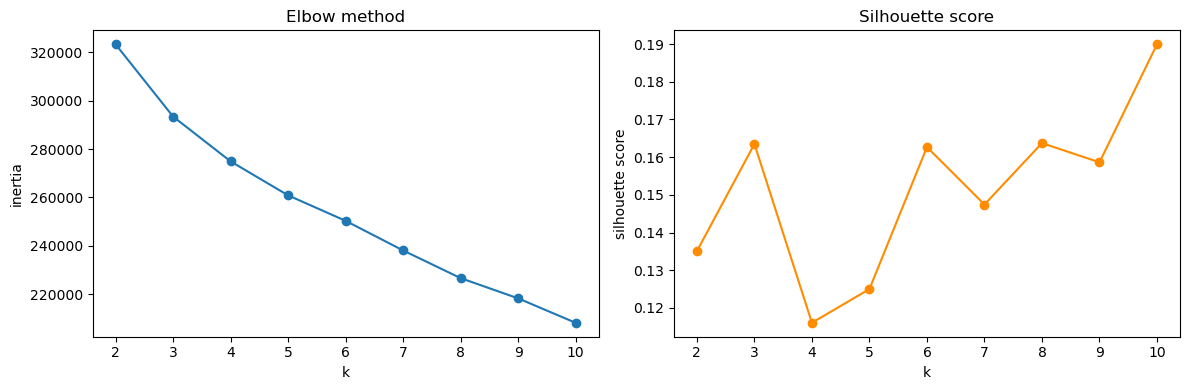

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('Silhouette score')

plt.tight_layout()
plt.show()

### Decision: k=3

The diagnostics don't point to one obviously-correct k — silhouette scores
are low across the whole tested range (0.12-0.19, nowhere close to the 1.0
that would indicate crisp, well-separated clusters), and inertia declines
smoothly with no single sharp elbow. Local silhouette peaks appear at k=3
(0.164), k=8 (0.164), and k=10 (0.190, the edge of the tested range — so
it's unconfirmed whether that's a genuine peak or just the trend still
rising).

**Choosing k=3**, for two reasons: it's a genuine local peak (not just
riding the edge of the search range like k=10), and per this project's
"simple + explainable over fancier + unexplained" convention, 3 segments
are far easier to interpret and name meaningfully than 8.

**Honest limitation to carry into the write-up**: silhouette scores this
low mean the resulting segments are real tendencies in the data, not sharp,
naturally-separated groups — Philadelphia businesses don't fall into
crisply distinct "types" on these features, they sit on more of a
continuum. Present the segments as descriptive groupings, not as strongly
validated distinct clusters.

In [6]:
final_k = 3
kmeans = KMeans(n_clusters=final_k, n_init=10, random_state=42)
business_features['segment'] = kmeans.fit_predict(X_scaled)

business_features['segment'].value_counts().sort_index()

segment
0    4149
1    9068
2    1343
Name: count, dtype: int64

## Profile and name the segments

To name each segment in plain language, look at its average feature values
(numeric) and most common categories, compared against the overall dataset
average — the goal is to describe what makes each segment distinct, not
just restate raw numbers.

In [7]:
profile = business_features.groupby('segment')[numeric_features].mean()
profile.loc['overall_mean'] = business_features[numeric_features].mean()
profile.T

segment,0,1,2,overall_mean
review_count_actual,26.166546,65.308337,198.591214,66.448420
sentiment_compound_mean,0.140761,0.723985,0.656468,0.551562
sentiment_compound_std,0.735931,0.410906,0.496703,0.511438
pct_negative_reviews,0.421709,0.088439,0.134260,0.187633
pct_positive_reviews,0.554188,0.898642,0.853867,0.796357
text_word_count_mean,119.743568,104.552835,112.500233,109.614628
text_exclamation_count_mean,1.166619,1.220069,1.098820,1.193654
text_question_count_mean,0.265676,0.147805,0.208193,0.186963
text_caps_word_ratio_mean,0.008547,0.004630,0.004991,0.005779
category_count,3.905760,4.294221,6.458675,4.383173


In [8]:
# top 5 categories by share within each segment (helps characterize "what kind of business" each segment skews toward)
for seg in sorted(business_features['segment'].unique()):
    seg_data = business_features[business_features['segment'] == seg]
    top5 = seg_data[category_features].mean().sort_values(ascending=False).head(5)
    print(f'--- segment {seg} (n={len(seg_data)}) ---')
    print(top5)
    print()

--- segment 0 (n=4149) ---
cat_restaurants           0.262714
cat_shopping              0.161244
cat_home_services         0.144854
cat_food                  0.139793
cat_health_and_medical    0.113762
dtype: float64

--- segment 1 (n=9068) ---
cat_restaurants        0.411998
cat_food               0.249669
cat_shopping           0.153727
cat_beauty_and_spas    0.106308
cat_sandwiches         0.072342
dtype: float64

--- segment 2 (n=1343) ---
cat_nightlife         0.989576
cat_bars              0.960536
cat_restaurants       0.763961
cat_american_(new)    0.256888
cat_food              0.194341
dtype: float64



### Naming the segments

Despite the modest silhouette scores, the three profiles tell a clear,
distinct story:

- **Segment 0 — "Struggling / Mixed-Experience Businesses"** (4,149
  businesses, 28.5%): lowest review volume, by far the lowest sentiment
  (0.14 vs. 0.55 overall), 42% negative reviews vs. 19% overall, and the
  most emotionally charged writing style (highest caps ratio, most
  question marks — reads as frustration/complaint language). No single
  dominant category — a broad mix rather than one business type.
- **Segment 1 — "Steady Mainstream Favorites"** (9,068 businesses, 62.3%,
  the majority): highest sentiment (0.72), most consistent reviews (lowest
  std), only 9% negative. Restaurant/food/shopping-heavy — the typical
  well-performing small business.
- **Segment 2 — "High-Traffic Bars & Nightlife"** (1,343 businesses,
  9.2%): roughly 3x the review volume of the other segments, tagged with
  the most categories on average, and overwhelmingly bars/nightlife (99%
  nightlife, 96% bars, 76% also tagged restaurants — bar/restaurant/
  nightlife combo venues). Positive-leaning sentiment, high engagement.

Worth noting for the write-up: Segment 0's sharply worse sentiment profile
is an interesting **independent cross-check** against the Phase 5b risk
proxy — it emerged purely from unsupervised clustering on review
text/behavior, without ever seeing `risk_proxy_closed`. Whether Segment 0
businesses are actually more likely to have closed is a natural question
for Phase 5b/6 to explore, not something to assume here.

## Save output

Saved as a **separate file**, not merged back into `business_features.csv`
— segmentation is one of three independent Phase 5 tasks, and folding its
output into the shared feature table would make 5b/5c implicitly depend on
5a having run first, which breaks that independence.

In [9]:
segment_names = {
    0: 'Struggling / Mixed-Experience Businesses',
    1: 'Steady Mainstream Favorites',
    2: 'High-Traffic Bars & Nightlife',
}
business_features['segment_name'] = business_features['segment'].map(segment_names)

business_segments = business_features[['business_id', 'name', 'segment', 'segment_name']]
business_segments.to_csv('../data/business_segments.csv', index=False)

business_segments['segment_name'].value_counts()

segment_name
Steady Mainstream Favorites                 9068
Struggling / Mixed-Experience Businesses    4149
High-Traffic Bars & Nightlife               1343
Name: count, dtype: int64